### Stan Model (different priors)

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng
import os
import arviz as az

# Import functions
from cmdstanpy import CmdStanModel
from tensorflow_probability.substrates import numpy as tfp
tfd = tfp.distributions

# Create ./stan folder if does not exists
if not os.path.exists("./stan"):
    os.mkdir("./stan")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import cmdstanpy
print(cmdstanpy.cmdstan_path())

/Users/sararedaelli/.cmdstan/cmdstan-2.37.0


In [3]:
#import modified dataset
data=pd.read_csv('/Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/data1.csv',sep=',')
data_donors=pd.read_csv('/Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/data_donors1.csv',sep=',')

In [4]:
data.head()

,Idx Experiment,Idx Replica Diluition,Idx Replica Experiment,Control,Diluition,IBU,DMSO,Temp,Count
0,1,1,1,0,-2,6.25,0,28,36
1,1,2,1,0,-2,6.25,0,28,33
2,1,3,1,0,-2,6.25,0,28,30
3,1,1,1,0,-3,6.25,0,28,4
4,1,2,1,0,-3,6.25,0,28,6


In [36]:
np.unique(data['Idx Replica Experiment'].values)

array([1, 2, 3])

In [37]:
data_donors.head()

,Idx Experiment,Idx Replica Experiment,Diluition,IBU,DMSO,Temp,Count
0,1,1,-6,6.25,0,28,51
1,1,2,-6,6.25,0,28,48
2,1,3,-6,6.25,0,28,50
3,1,1,-7,6.25,0,28,7
4,1,2,-7,6.25,0,28,3


In [4]:
#Extract the data we need for the Stan model 
#from trasconjugant dataset
Y=data.Count.values
N=len(Y)
idx_experiment=data['Idx Experiment'].values
I=len(np.unique(idx_experiment))
idx_experiment_replica=data['Idx Replica Experiment'].values
J=len(np.unique(idx_experiment_replica))
dil_trasc=data['Diluition'].values
rho_trasc = np.power(10.0, dil_trasc)


#from donor dataset
D=data_donors.Count.values
M=len(D)
idx_donor_experiment=data_donors['Idx Experiment'].values
dil_donor=data_donors['Diluition'].values
rho_donor=np.power(10.0, dil_donor)


#build design matrix X
IBU=data['IBU'].values
IBU=(IBU-np.mean(IBU))/np.std(IBU)
DMSO=data['DMSO'].values
DMSO=(DMSO-np.mean(DMSO))/np.std(DMSO)
Temp=data['Temp'].values
Temp=(Temp-np.mean(Temp))/np.std(Temp)
X=np.column_stack([np.ones_like(Y),IBU,DMSO,Temp])



##### Stan Model

In [5]:
glm1 = """
data {
    int<lower=0> N; 
    int<lower=0> M; 
    int<lower=0> p; 
    int<lower=0> I;
    int<lower=0> J;
    array[N] int<lower=0> Y;
    array[M] int<lower=0> D;
    matrix[N, p] X;
    vector[N] rho_trasc;
    vector[M] rho_donor;
    array[N] int idx_experiment;
    array[N] int idx_experiment_replica;
    array[M] int idx_donor_experiment;
}

parameters {
    vector[p] beta;
    matrix[I, J] beta_random;
    vector<lower=0>[I] alpha;
    real<lower=0> sigma_beta_sq;
    real<lower=0> tau_sq;
    real mu_chi;
    real<lower=0> sigma_chi;
    real<lower=0> phi_y;
}


transformed parameters {
    vector[N] mu;
    for(i in 1:N) {
      mu[i] = alpha[idx_experiment[i]]* exp(row(X, i) * beta + beta_random[idx_experiment[i], idx_experiment_replica[i]]);
    }
    real<lower=0> sigma_beta = sqrt(sigma_beta_sq);
    real<lower=0> tau = sqrt(tau_sq);
}

model {   
    for (s in 1:N) {
        Y[s] ~ neg_binomial_2(rho_trasc[s] * mu[s], phi_y);


    }
    phi_y ~ normal(0, 2);


    for (l in 1:M){
        D[l] ~ poisson(rho_donor[l] * alpha[idx_donor_experiment[l]]);
    }

    for (m in 1:I) {
        log(alpha[m])~normal(mu_chi, sigma_chi);

    }
    mu_chi ~ normal(0,1);
    sigma_chi ~ normal(0,1); 
    

    for (k in 1:p) {
        beta[k] ~ normal(0.0, tau);
        
    }

    tau_sq ~ inv_gamma(2, 1); 
    
    for (i in 1:I) {    
        for (j in 1:J) {
            beta_random[i,j] ~ normal(0, sigma_beta);
        }
    }
    sigma_beta_sq ~ inv_gamma(2, 1);  
 
}

generated quantities {
  vector[N] log_lik;
  array[N] int<lower=0> Y_rep;

  for (j in 1:N) {
    log_lik[j] = neg_binomial_2_lpmf(Y[j] | rho_trasc[j] * mu[j], phi_y);
  }

  for (n in 1:N) {
    Y_rep[n] = neg_binomial_2_rng(rho_trasc[n] * mu[n], phi_y);
  } 
}
"""


# Write stan model to file
stan_file = "./stan/glm1.stan"
with open(stan_file, "w") as f:
    print(glm1, file=f)

# Compile stan model
glm1 = CmdStanModel(stan_file=stan_file)

17:29:44 - cmdstanpy - INFO - compiling stan file /Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/stan/glm1.stan to exe file /Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/stan/glm1
17:30:13 - cmdstanpy - INFO - compiled model executable: /Users/sararedaelli/Desktop/transconjugacy_efficacy_PROJECT/stan/glm1


In [6]:
# Input data
glm1_data = {
    "N": N,
    "M": M,
    "I":I,
    "J":J,
    "p": X.shape[1],
    "Y": Y,
    "D": D,
    "X": X,
    "rho_trasc": rho_trasc,
    "rho_donor": rho_donor,
    "idx_experiment": idx_experiment,
    "idx_experiment_replica": idx_experiment_replica,
    "idx_donor_experiment": idx_donor_experiment
}

# Sample
glm1_fit = glm1.sample(data=glm1_data, chains=4, parallel_chains=4, 
                             iter_warmup=1000, iter_sampling=5000,show_console=True)

# Convert to arviz data type
poi_glm1_data = az.from_cmdstanpy(glm1_fit)

17:30:21 - cmdstanpy - INFO - Chain [1] start processing
17:30:21 - cmdstanpy - INFO - Chain [2] start processing
17:30:21 - cmdstanpy - INFO - Chain [3] start processing
17:30:21 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 5000
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/17/4ypkwf497x10dw9zl6kjtsg80000gn/T/tmp2c3b7wi4/2rlf2w_l.json
Chain [1] init = 2 (Default)
Chain [1] ra

17:31:31 - cmdstanpy - INFO - Chain [1] done processing


Chain [3] Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain [1] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 12.458 seconds (Warm-up)
Chain [1] 57.451 seconds (Sampling)
Chain [1] 69.909 seconds (Total)
Chain [1] 
Chain [1] 
Chain [2] Iteration: 5100 / 6000 [ 85%]  (Sampling)
Chain [4] Iteration: 5600 / 6000 [ 93%]  (Sampling)
Chain [3] Iteration: 5900 / 6000 [ 98%]  (Sampling)
Chain [2] Iteration: 5200 / 6000 [ 86%]  (Sampling)
Chain [4] Iteration: 5700 / 6000 [ 95%]  (Sampling)
Chain [3] Iteration: 6000 / 6000 [100%]  (Sampling)


17:31:32 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] 
Chain [3] Elapsed Time: 13.245 seconds (Warm-up)
Chain [3] 58.09 seconds (Sampling)
Chain [3] 71.335 seconds (Total)
Chain [3] 
Chain [3] 
Chain [2] Iteration: 5300 / 6000 [ 88%]  (Sampling)
Chain [4] Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain [2] Iteration: 5400 / 6000 [ 90%]  (Sampling)
Chain [4] Iteration: 5900 / 6000 [ 98%]  (Sampling)


17:31:34 - cmdstanpy - INFO - Chain [4] done processing


Chain [2] Iteration: 5500 / 6000 [ 91%]  (Sampling)
Chain [4] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 11.154 seconds (Warm-up)
Chain [4] 62.098 seconds (Sampling)
Chain [4] 73.252 seconds (Total)
Chain [4] 
Chain [4] 
Chain [2] Iteration: 5600 / 6000 [ 93%]  (Sampling)
Chain [2] Iteration: 5700 / 6000 [ 95%]  (Sampling)
Chain [2] Iteration: 5800 / 6000 [ 96%]  (Sampling)
Chain [2] Iteration: 5900 / 6000 [ 98%]  (Sampling)


17:31:37 - cmdstanpy - INFO - Chain [2] done processing
17:31:37 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_lpmf: Location parameter is inf, but must be positive finite! (in 'glm1.stan', line 41, column 8 to column 59)
	Exception: neg_binomial_2_lpmf: Location parameter is inf, but must be positive finite! (in 'glm1.stan', line 41, column 8 to column 59)
	Exception: neg_binomial_2_lpmf: Location parameter is inf, but must be positive finite! (in 'glm1.stan', line 41, column 8 to column 59)
	Exception: neg_binomial_2_lpmf: Location parameter is inf, but must be positive finite! (in 'glm1.stan', line 41, column 8 to column 59)
	Exception: neg_binomial_2_lpmf: Location parameter is inf, but must be positive finite! (in 'glm1.stan', line 41, column 8 to column 59)
	Exception: neg_binomial_2_lpmf: Location parameter is inf, but must be positive finite! (in 'glm1.stan', line 41, column 8 to column 59)
Exception: neg_binomial_2_lpmf: Location parameter 

Chain [2] Iteration: 6000 / 6000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 11.955 seconds (Warm-up)
Chain [2] 63.932 seconds (Sampling)
Chain [2] 75.887 seconds (Total)
Chain [2] 
Chain [2] 


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (28), generating only 20 plots
  warnings.warn(


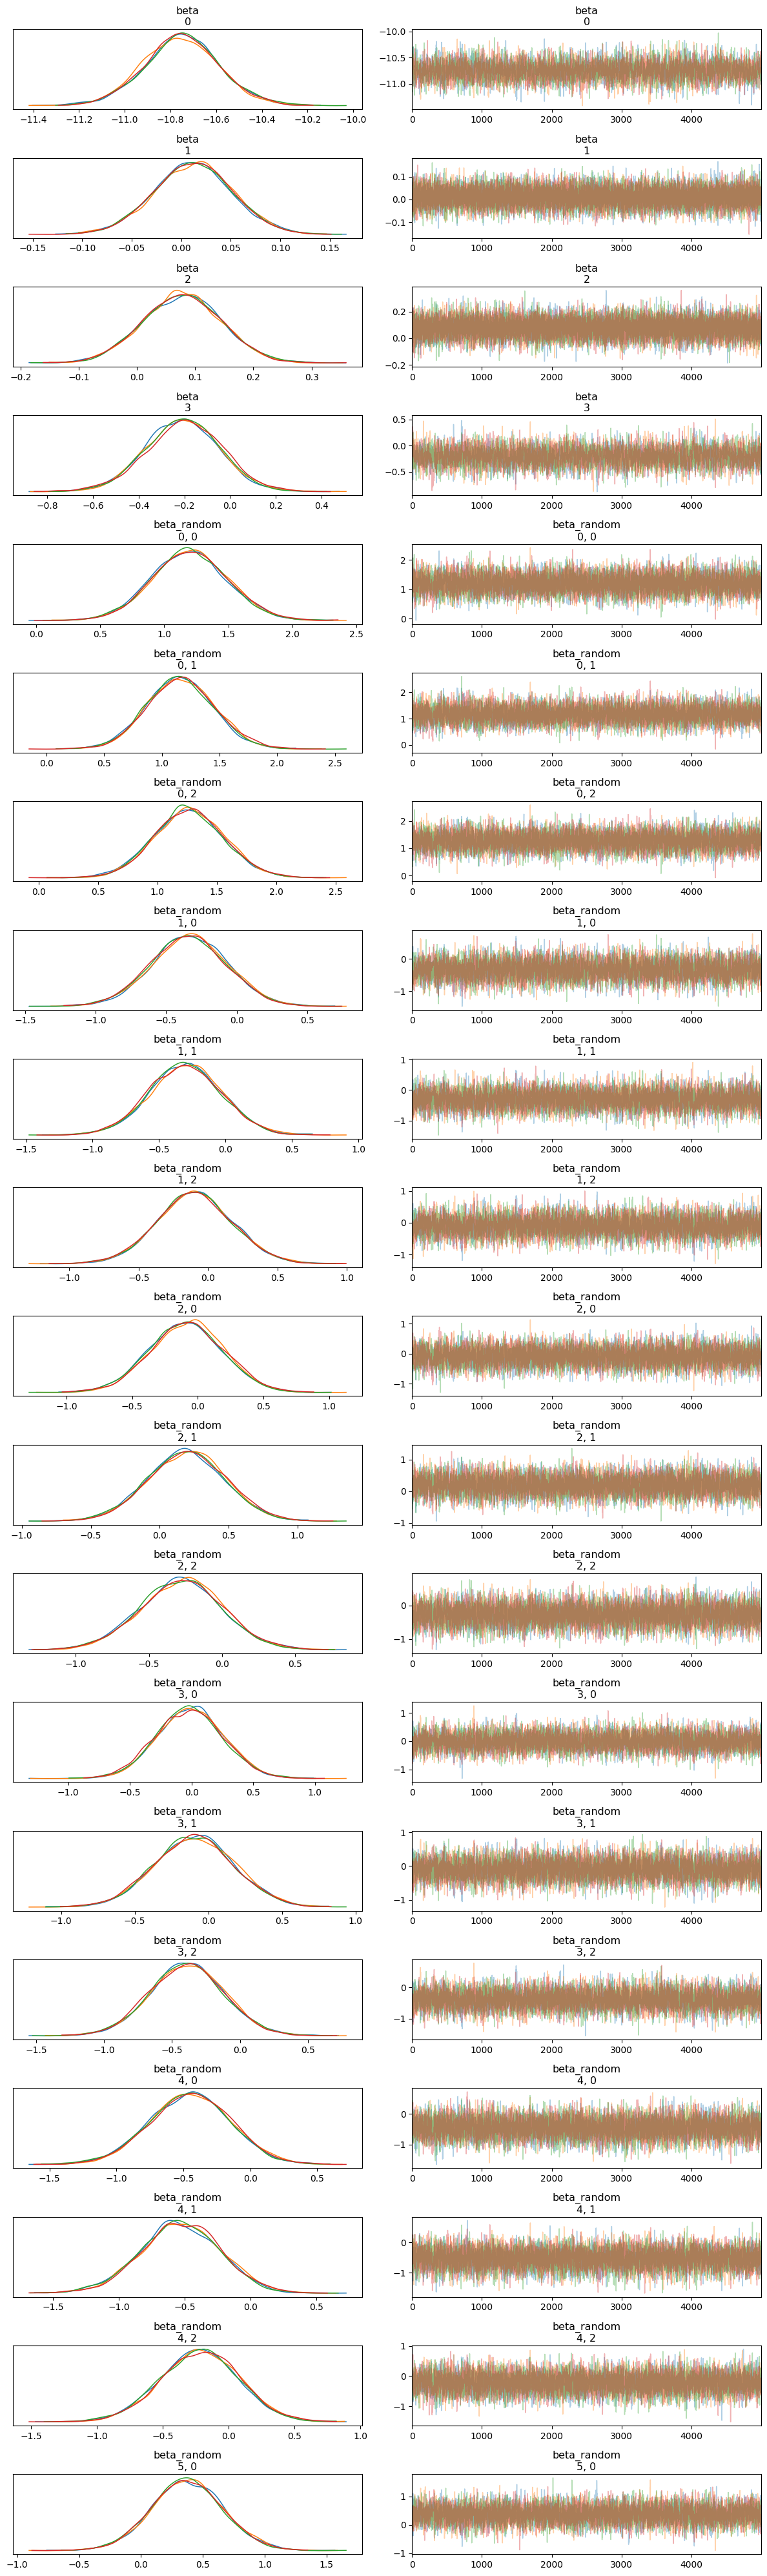

In [7]:
az.plot_trace(poi_glm1_data, var_names=["beta", "beta_random"], compact=False)
plt.tight_layout()
plt.show()

divergence <xarray.DataArray 'diverging' ()> Size: 8B
array(0)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (112) in plot_autocorr, generating only 40 plots
  warnings.warn(


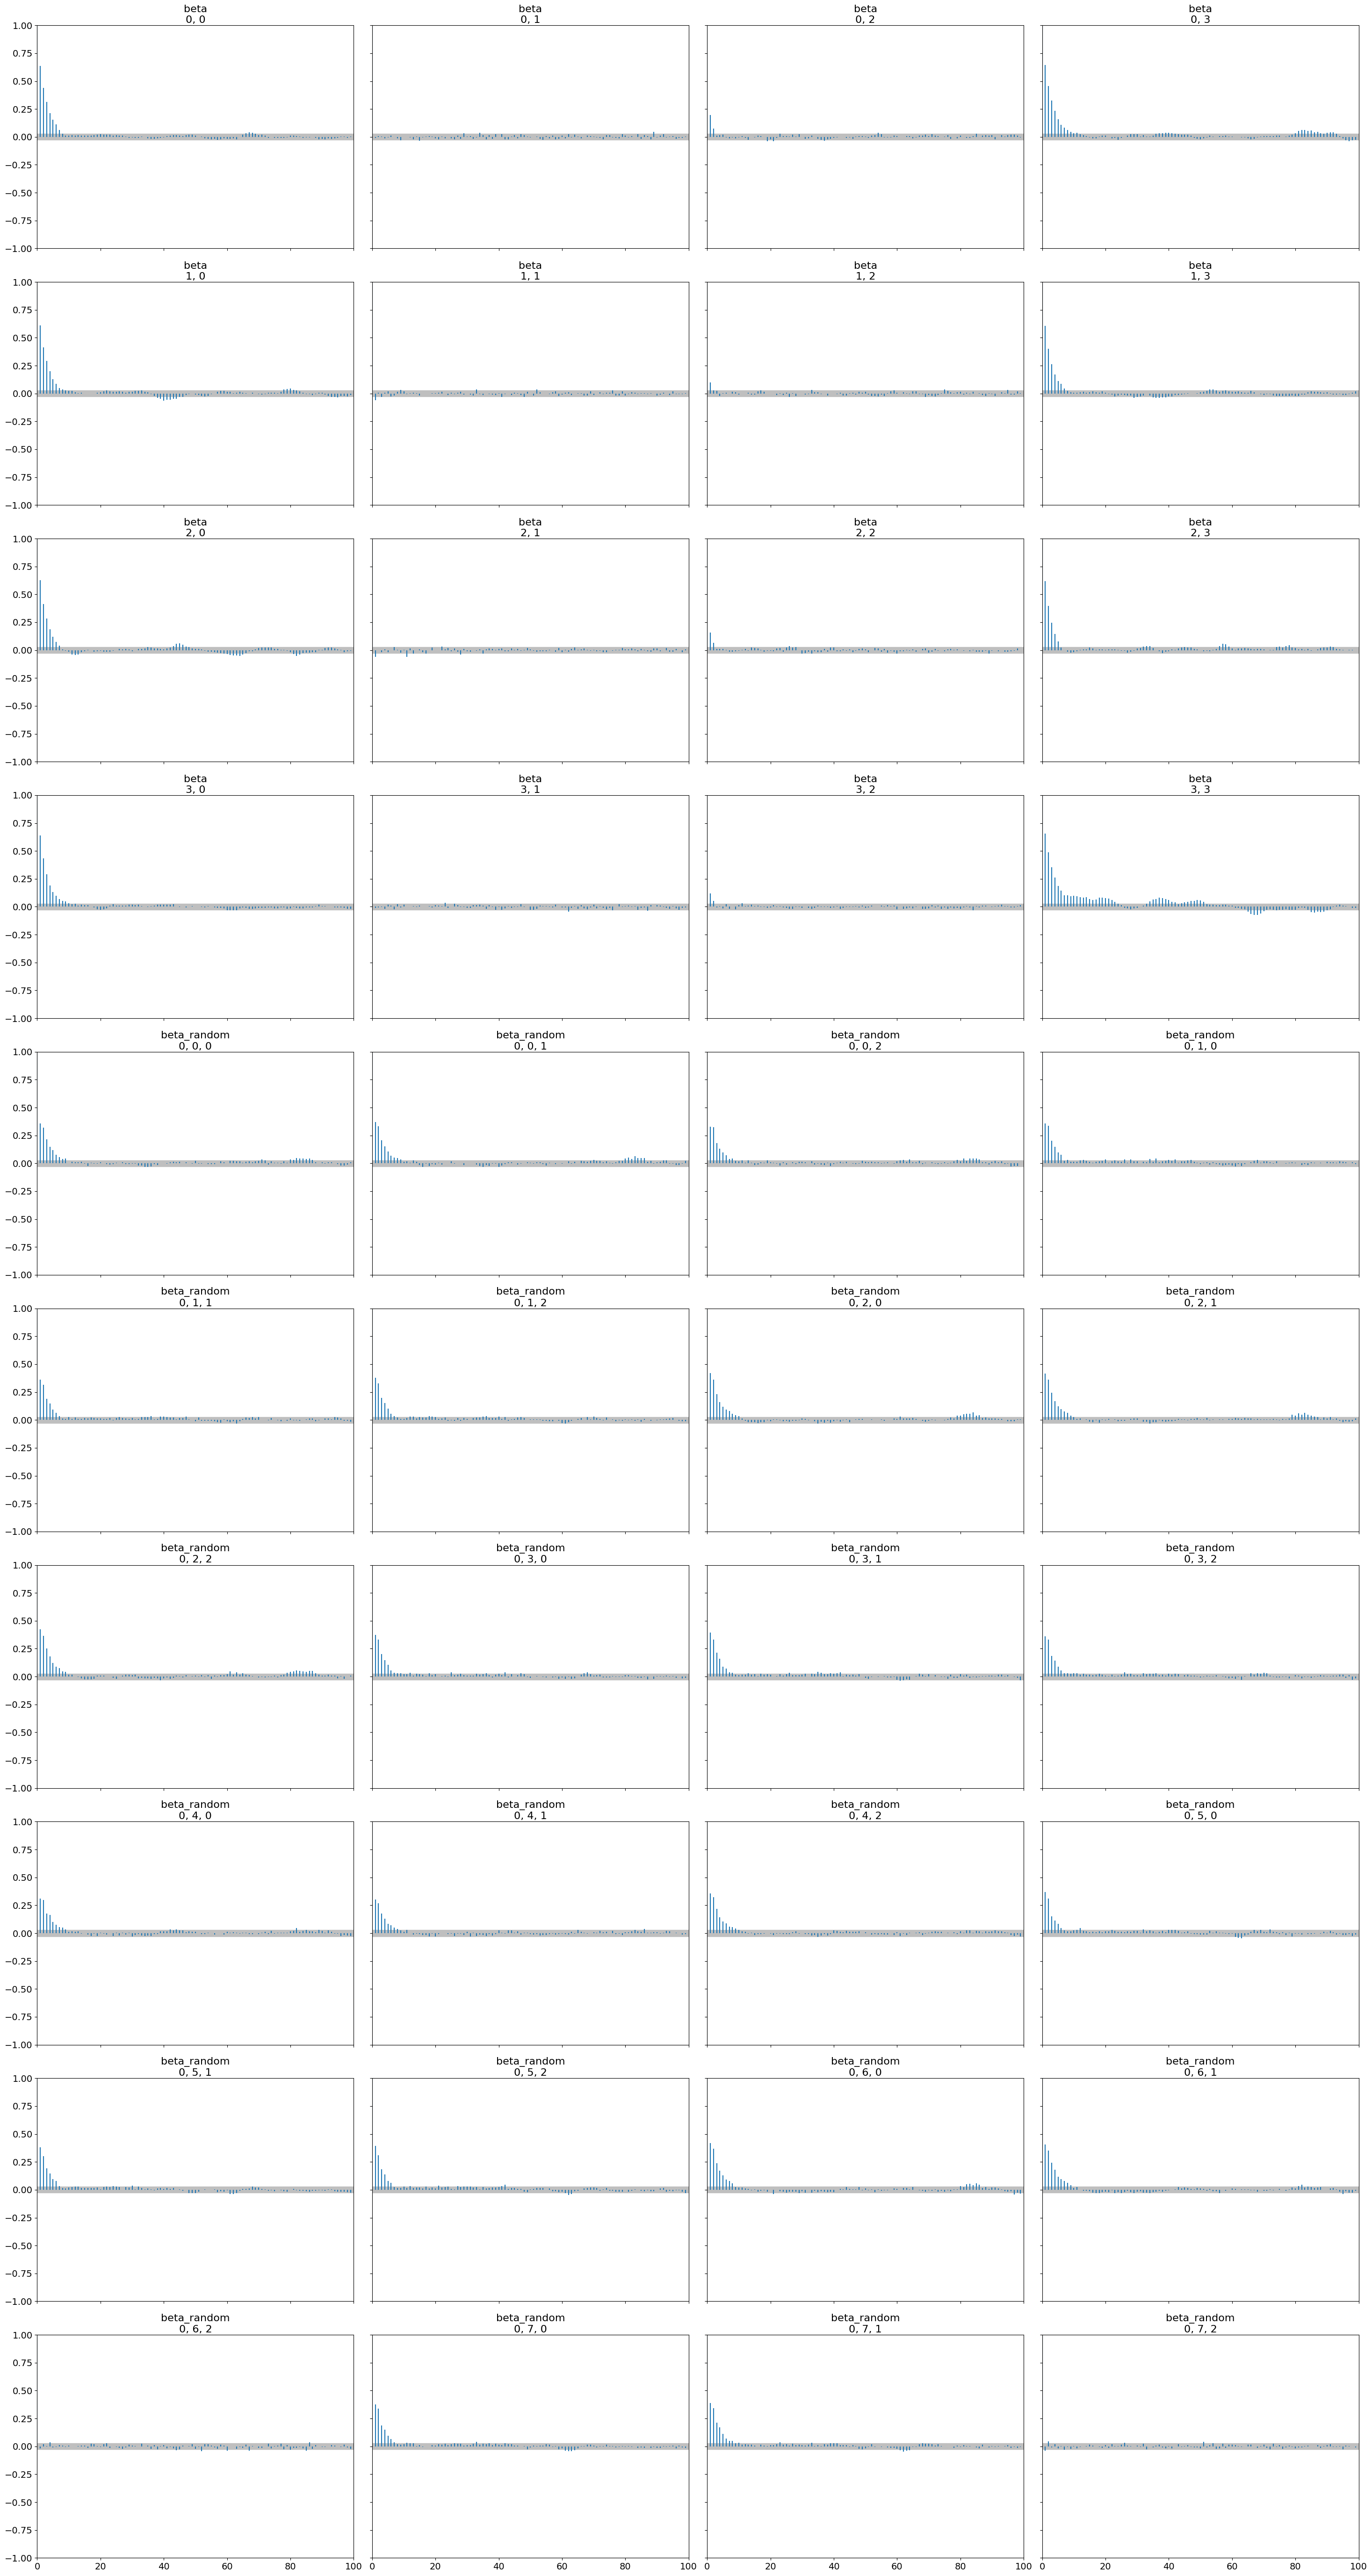

In [8]:
#check MCMC chain
print("divergence",np.sum(poi_glm1_data.sample_stats.diverging))
#no divergence!!!!

#plot the autocorrelation plots
az.plot_autocorr(poi_glm1_data, var_names=["beta", "beta_random"])
plt.tight_layout()
plt.show() 




In [9]:
#EFFECTIVE SAMPLE SIZE for all parameters
ess = az.ess(poi_glm1_data)

# vettore ESS per beta
ess_beta = ess["beta"].values
print("ESS beta:", ess_beta)

# matrice ESS per beta_random
ess_br = ess["beta_random"].values
print("ESS beta_random shape:", ess_br.shape)
print(ess_br)

#vettore ESS per alpha
ess_alpha = ess["alpha"].values
print("ESS alpha:", ess_alpha)

#ESS per tau_sq
ess_tau_sq = ess["tau_sq"].values
print("ESS tau_sq:", ess_tau_sq)

#ESS per sigma_beta_sq
ess_sigma_beta_sq = ess["sigma_beta_sq"].values
print("ESS sigma_beta_sq:", ess_sigma_beta_sq)

#ESS per mu_chi
ess_mu_chi = ess["mu_chi"].values
print("ESS mu_chi:", ess_mu_chi)

#ESS per sigma_chi
ess_sigma_chi = ess["sigma_chi"].values
print("ESS sigma_chi:", ess_sigma_chi)



ESS beta: [ 4162.06470223 21453.26938696 13866.74518715  3623.71604158]
ESS beta_random shape: (8, 3)
[[ 5973.26418267  5831.19353398  6109.36638371]
 [ 4805.76811998  5078.96555111  5110.36419034]
 [ 5299.7215606   5378.60598563  5228.51580849]
 [ 4850.43321341  4973.82021935  5059.9646466 ]
 [ 5890.35234088  6311.00104293  5955.81171488]
 [ 5314.49665303  5207.53931239  5130.15431475]
 [ 5196.22390114  5338.41114163 20073.35083267]
 [ 4723.40495386  4778.82153079 19968.62719516]]
ESS alpha: [20071.3106979  22028.64157035 20539.60208145 21956.23500682
 21850.6185755  21405.3144075  20457.1426403  21566.39115729]
ESS tau_sq: 23175.578247976202
ESS sigma_beta_sq: 14209.804606259606
ESS mu_chi: 21028.058609095337
ESS sigma_chi: 20412.58976818028


### Posterior predictive check 

In [11]:
# posterior plot (sorted by fitted mean + log scale)
def posterior_predictive_check(yrep, yobs, q_low=0.05, q_high=0.95):

    # compute mean and CI for every observation
    pred_mean = yrep.mean(axis=0)                      # (N,)
    pred_lo   = np.quantile(yrep, q_low,  axis=0)      # (N,)
    pred_hi   = np.quantile(yrep, q_high, axis=0)      # (N,)

    # identify outliers in original scale
    out = (yobs < pred_lo) | (yobs > pred_hi)

    # sort by fitted mean (in original scale)
    order = np.argsort(pred_mean)

    # apply ordering
    yobs_s      = yobs[order]
    pred_mean_s = pred_mean[order]
    pred_lo_s   = pred_lo[order]
    pred_hi_s   = pred_hi[order]
    out_s       = out[order]

    # x-axis is now "rank by fitted mean"
    x = np.arange(len(yobs))

    # log scale for plotting (safe with zeros)
    yobs_l      = np.log1p(yobs_s)
    pred_mean_l = np.log1p(pred_mean_s)
    pred_lo_l   = np.log1p(pred_lo_s)
    pred_hi_l   = np.log1p(pred_hi_s)

    plt.figure(figsize=(12, 5))

    # predictive band (log scale)
    plt.fill_between(
        x, pred_lo_l, pred_hi_l,
        alpha=0.3,
        label=f"{int((q_high-q_low)*100)}% posterior predictive interval (log1p)"
    )

    # predictive mean (log scale)
    plt.scatter(
        x, pred_mean_l,
        linewidth=2,
        label="log(1 + predicted mean)",
        zorder=2
    )

    # observed inliers/outliers (log scale)
    plt.scatter(
        x[~out_s], yobs_l[~out_s],
        s=18,
        label="Observed (inliers)",
        zorder=3
    )
    plt.scatter(
        x[out_s], yobs_l[out_s],
        s=35,
        color="red",
        label="Observed (outliers)",
        zorder=4
    )

    plt.xlabel("Observations (sorted by fitted mean)")
    plt.ylabel("log(1 + y)")
    plt.title(f"PPC (sorted, log-scale) — outliers: {out.sum()} / {len(out)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # return outliers in original order + ordering used (useful to map back)
    return out, order



<Figure size 1000x500 with 0 Axes>

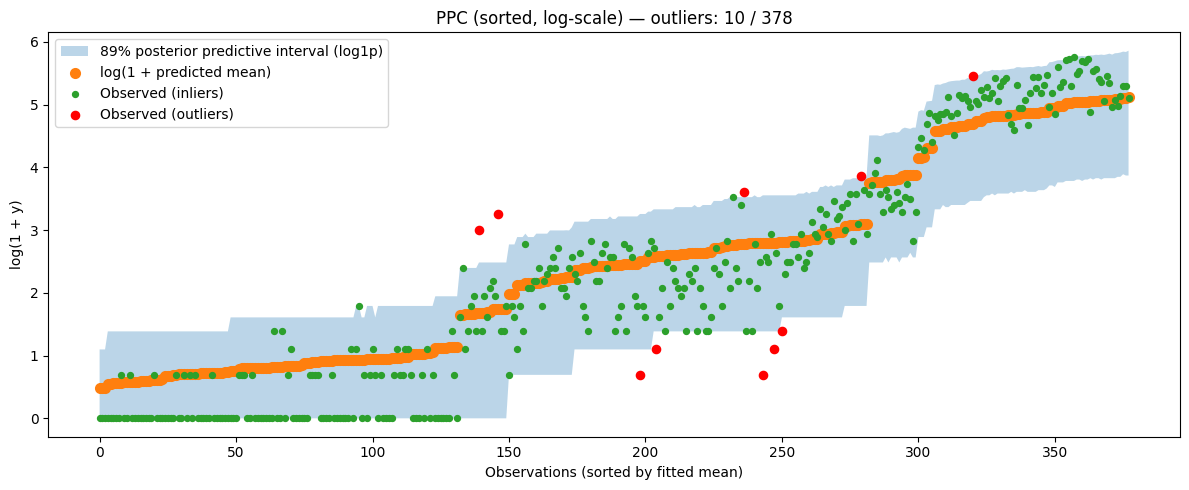

NameError: name 'key' is not defined

In [12]:
#posterior predictive check



idata = poi_glm1_data

# Posterior predictive replicates: (chain, draw, N)
yrep = idata.posterior["Y_rep"].values

    # Observed data 
yobs = data["Count"]
    

    # Flatten chain+draw -> (S, N)
S = yrep.shape[0] * yrep.shape[1]
yrep = yrep.reshape(S, yrep.shape[2])

    # Plot
plt.figure(figsize=(10, 5))
posterior_predictive_check(yrep, yobs)
plt.suptitle(f"Posterior Predictive Check: {key}", fontsize=16)
plt.show()

##### Prior vs posterior

In [70]:
#prior fit
glm1_fit_prior = glm1.sample(
    data=glm1_data,
    chains=4,
    parallel_chains=4,
    iter_sampling=10000,
    iter_warmup=1,
    fixed_param=True,
    adapt_engaged=False,
    show_console=True
)


16:56:42 - cmdstanpy - INFO - Chain [1] start processing
16:56:42 - cmdstanpy - INFO - Chain [2] start processing
16:56:42 - cmdstanpy - INFO - Chain [3] start processing
16:56:42 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 10000
Chain [1] num_warmup = 1
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = fixed_param
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/17/4ypkwf497x10dw9zl6kjtsg80000gn/T/tmp_b010n4e/kpffiao_.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 1498
Chain [1] output
Chain [1] file = /var/folders/17/4ypkwf497x10dw9zl6kjtsg80000gn/T/tmp_b010n4e/glm18x43bl_l/glm1-20260129165642_1.csv
Chain [1] diagnostic_file =  (Default)
Chain [1] refresh = 100 (Default)
Chain [1] sig_figs = 8

16:56:55 - cmdstanpy - INFO - Chain [1] done processing
16:56:55 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 9900 / 10000 [ 99%]  (Sampling)
Chain [1] 
Chain [4] Iteration: 9700 / 10000 [ 97%]  (Sampling)
Chain [4] Iteration: 9800 / 10000 [ 98%]  (Sampling)
Chain [2] Iteration: 9800 / 10000 [ 98%]  (Sampling)
Chain [4] Iteration: 9900 / 10000 [ 99%]  (Sampling)
Chain [3] Iteration: 10000 / 10000 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 0 seconds (Warm-up)
Chain [3] 13.136 seconds (Sampling)
Chain [3] 13.136 seconds (Total)
Chain [3] 
Chain [3] 
Chain [2] Iteration: 9900 / 10000 [ 99%]  (Sampling)
Chain [4] Iteration: 10000 / 10000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 0 seconds (Warm-up)
Chain [4] 13.171 seconds (Sampling)
Chain [4] 13.171 seconds (Total)
Chain [4] 


16:56:55 - cmdstanpy - INFO - Chain [4] done processing
16:56:55 - cmdstanpy - INFO - Chain [2] done processing


Chain [4] 
Chain [2] Iteration: 10000 / 10000 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 0 seconds (Warm-up)
Chain [2] 13.322 seconds (Sampling)
Chain [2] 13.322 seconds (Total)
Chain [2] 
Chain [2] 


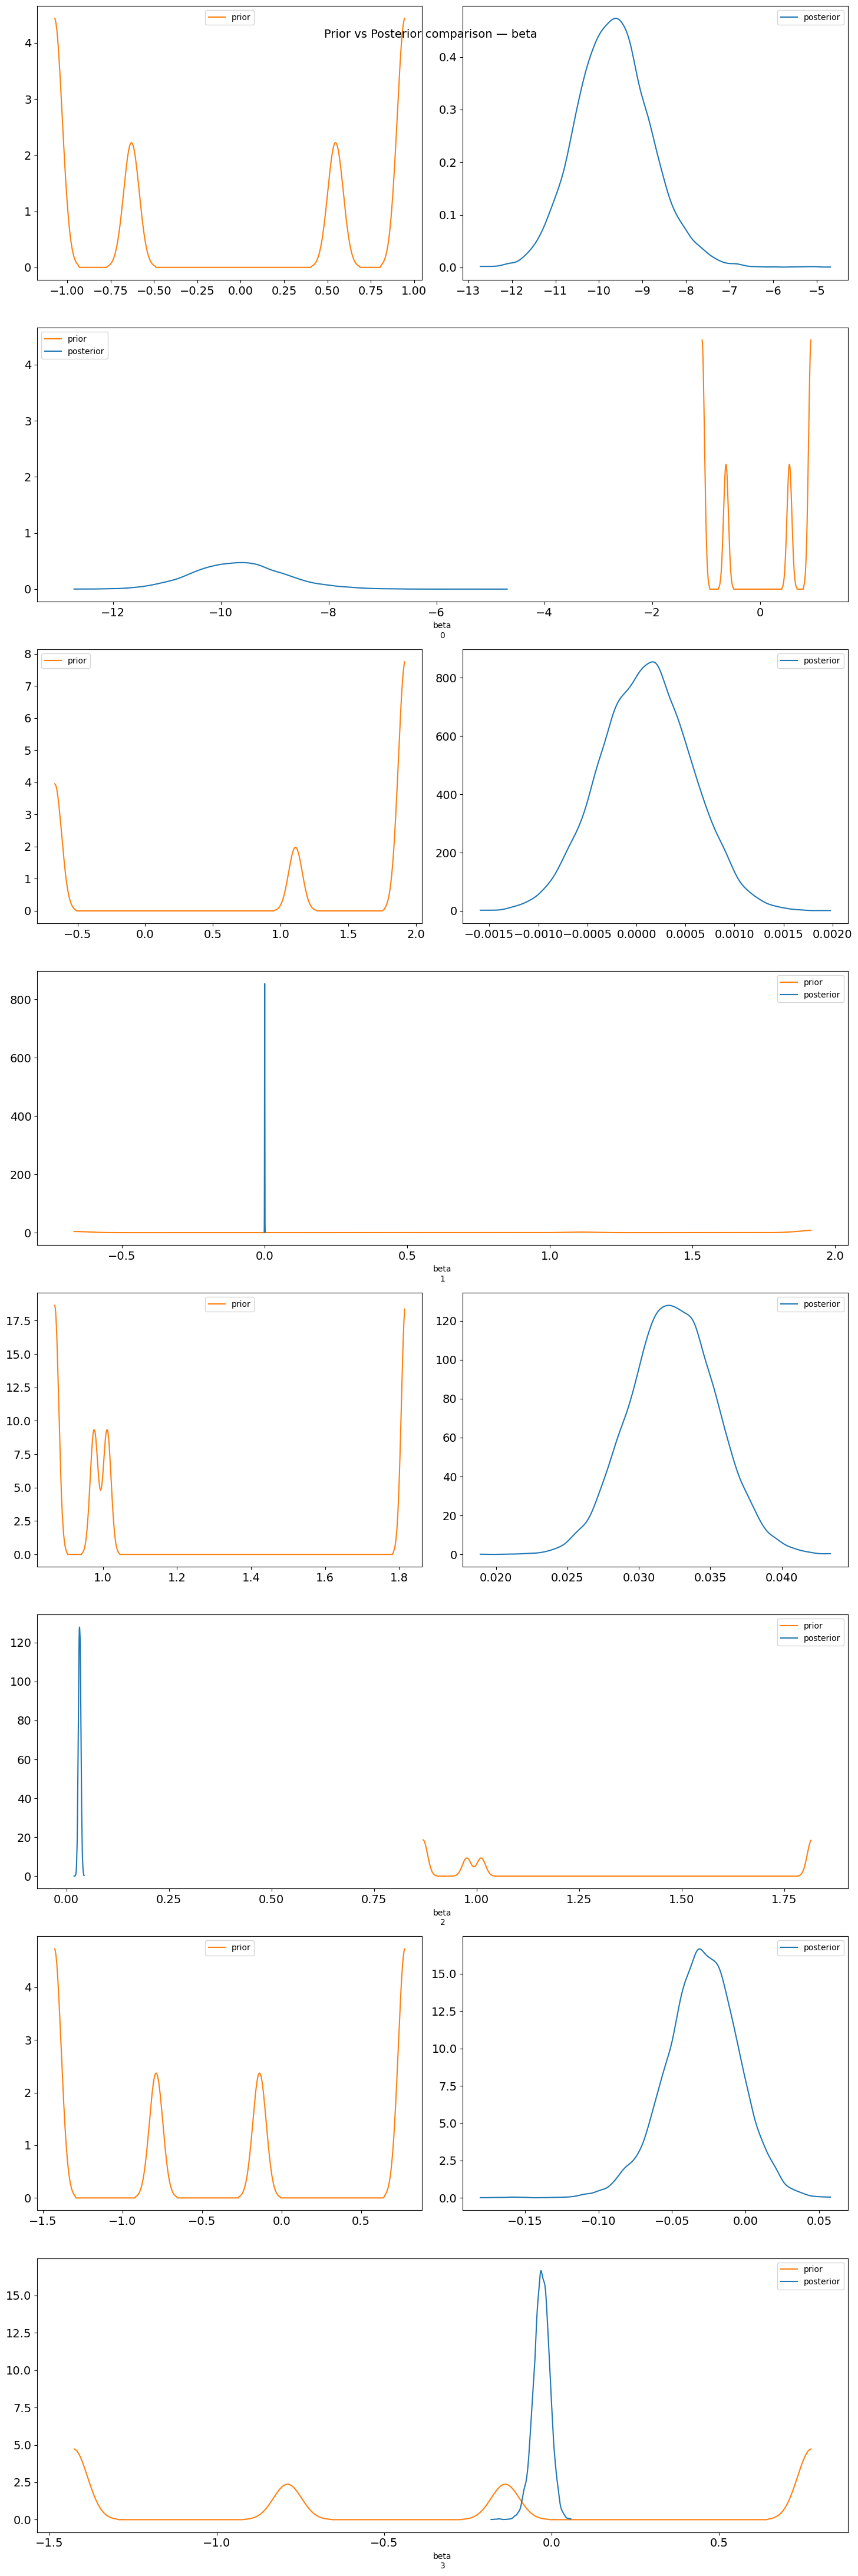

In [71]:

idata_post = az.from_cmdstanpy(posterior=glm1_fit, log_likelihood="log_lik")
idata_prior = az.from_cmdstanpy(prior=glm1_fit_prior)

idata = az.concat(idata_post, idata_prior)

axes = az.plot_dist_comparison(
    idata,
    var_names=["beta"]
)

plt.suptitle("Prior vs Posterior comparison — beta", fontsize=14)
plt.tight_layout()
plt.show()


##### Posterior confidence intervals 

In [47]:
glm1_fit.summary()

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
lp__,68879.200000,0.058864,4.599560,4.553810,68871.200000,68879.600000,68886.100000,6337.50,9804.70,1.811230,1.00067
beta[1],-9.662620,0.016321,0.867567,0.834255,-11.030700,-9.685250,-8.203100,3049.74,4018.29,0.871605,1.00199
beta[2],0.000091,0.000003,0.000467,0.000469,-0.000684,0.000094,0.000862,20648.80,12187.10,5.901350,1.00045
beta[3],0.032395,0.000020,0.003014,0.003015,0.027472,0.032383,0.037370,23084.70,14472.90,6.597530,1.00044
beta[4],-0.030129,0.000478,0.025037,0.023687,-0.072263,-0.029478,0.009300,2997.30,3723.62,0.856618,1.00211
...,...,...,...,...,...,...,...,...,...,...,...
log_lik[374],-2.541380,0.001108,0.136383,0.094037,-2.815430,-2.494080,-2.421770,18081.00,13945.10,5.167490,1.00047
log_lik[375],-3.192190,0.002905,0.393784,0.384212,-3.903380,-3.143960,-2.629450,18856.20,13965.60,5.389020,1.00068
log_lik[376],-2.177860,0.001073,0.147184,0.147140,-2.423880,-2.173460,-1.941120,18856.10,13965.60,5.389020,1.00066
log_lik[377],-1.401800,0.000582,0.079657,0.079282,-1.538510,-1.397140,-1.277850,18856.20,13965.60,5.389020,1.00067


array([<Axes: title={'center': 'beta\n0'}>,
       <Axes: title={'center': 'beta\n1'}>,
       <Axes: title={'center': 'beta\n2'}>,
       <Axes: title={'center': 'beta\n3'}>], dtype=object)

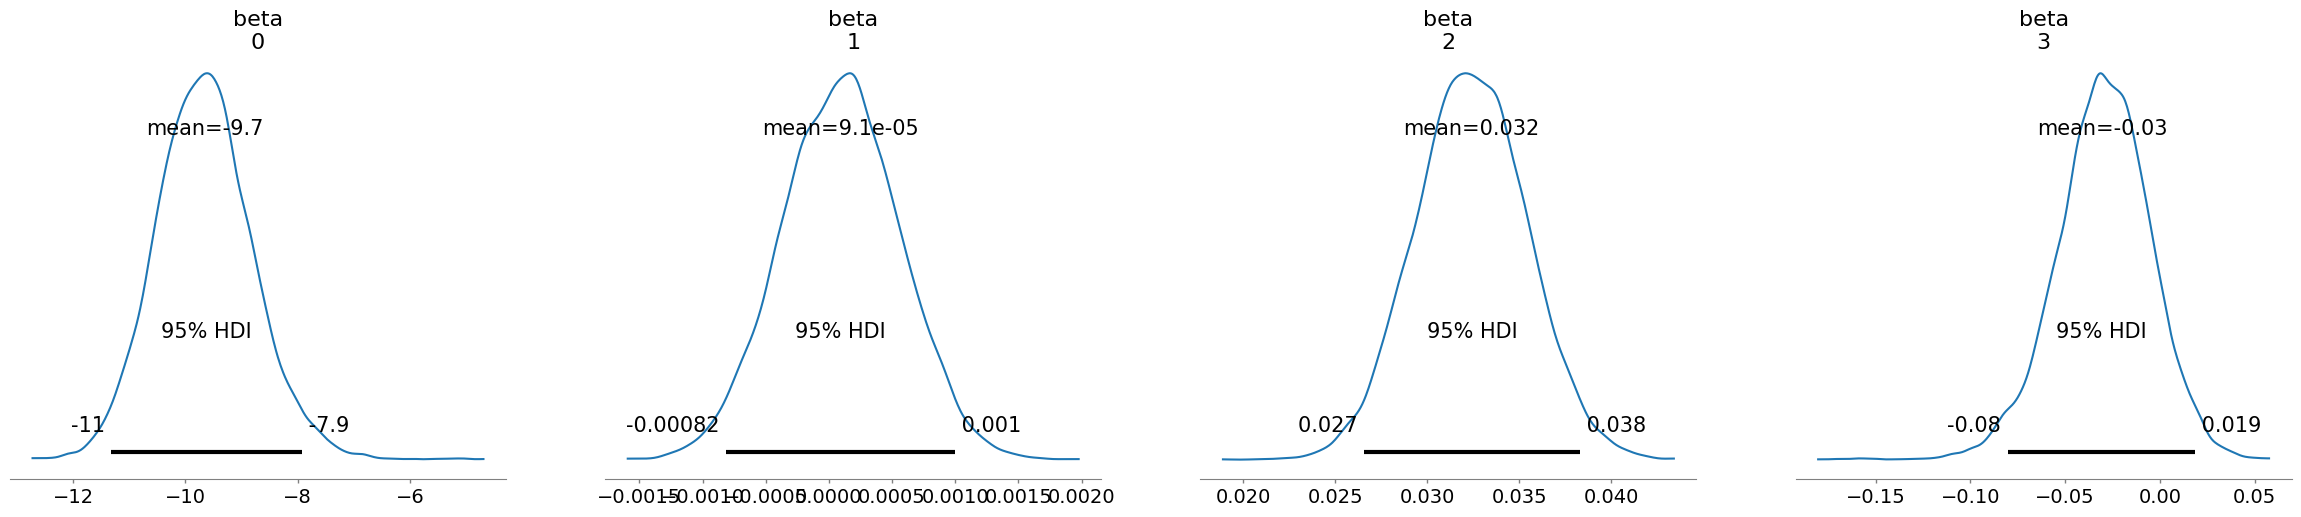

In [ ]:
#plot posterior for beta
az.plot_posterior(poi_glm1_data, var_names=["beta"], hdi_prob=0.95)

array([[<Axes: title={'center': 'beta_random\n0, 0'}>,
        <Axes: title={'center': 'beta_random\n0, 1'}>,
        <Axes: title={'center': 'beta_random\n0, 2'}>,
        <Axes: title={'center': 'beta_random\n1, 0'}>],
       [<Axes: title={'center': 'beta_random\n1, 1'}>,
        <Axes: title={'center': 'beta_random\n1, 2'}>,
        <Axes: title={'center': 'beta_random\n2, 0'}>,
        <Axes: title={'center': 'beta_random\n2, 1'}>],
       [<Axes: title={'center': 'beta_random\n2, 2'}>,
        <Axes: title={'center': 'beta_random\n3, 0'}>,
        <Axes: title={'center': 'beta_random\n3, 1'}>,
        <Axes: title={'center': 'beta_random\n3, 2'}>],
       [<Axes: title={'center': 'beta_random\n4, 0'}>,
        <Axes: title={'center': 'beta_random\n4, 1'}>,
        <Axes: title={'center': 'beta_random\n4, 2'}>,
        <Axes: title={'center': 'beta_random\n5, 0'}>],
       [<Axes: title={'center': 'beta_random\n5, 1'}>,
        <Axes: title={'center': 'beta_random\n5, 2'}>,
      

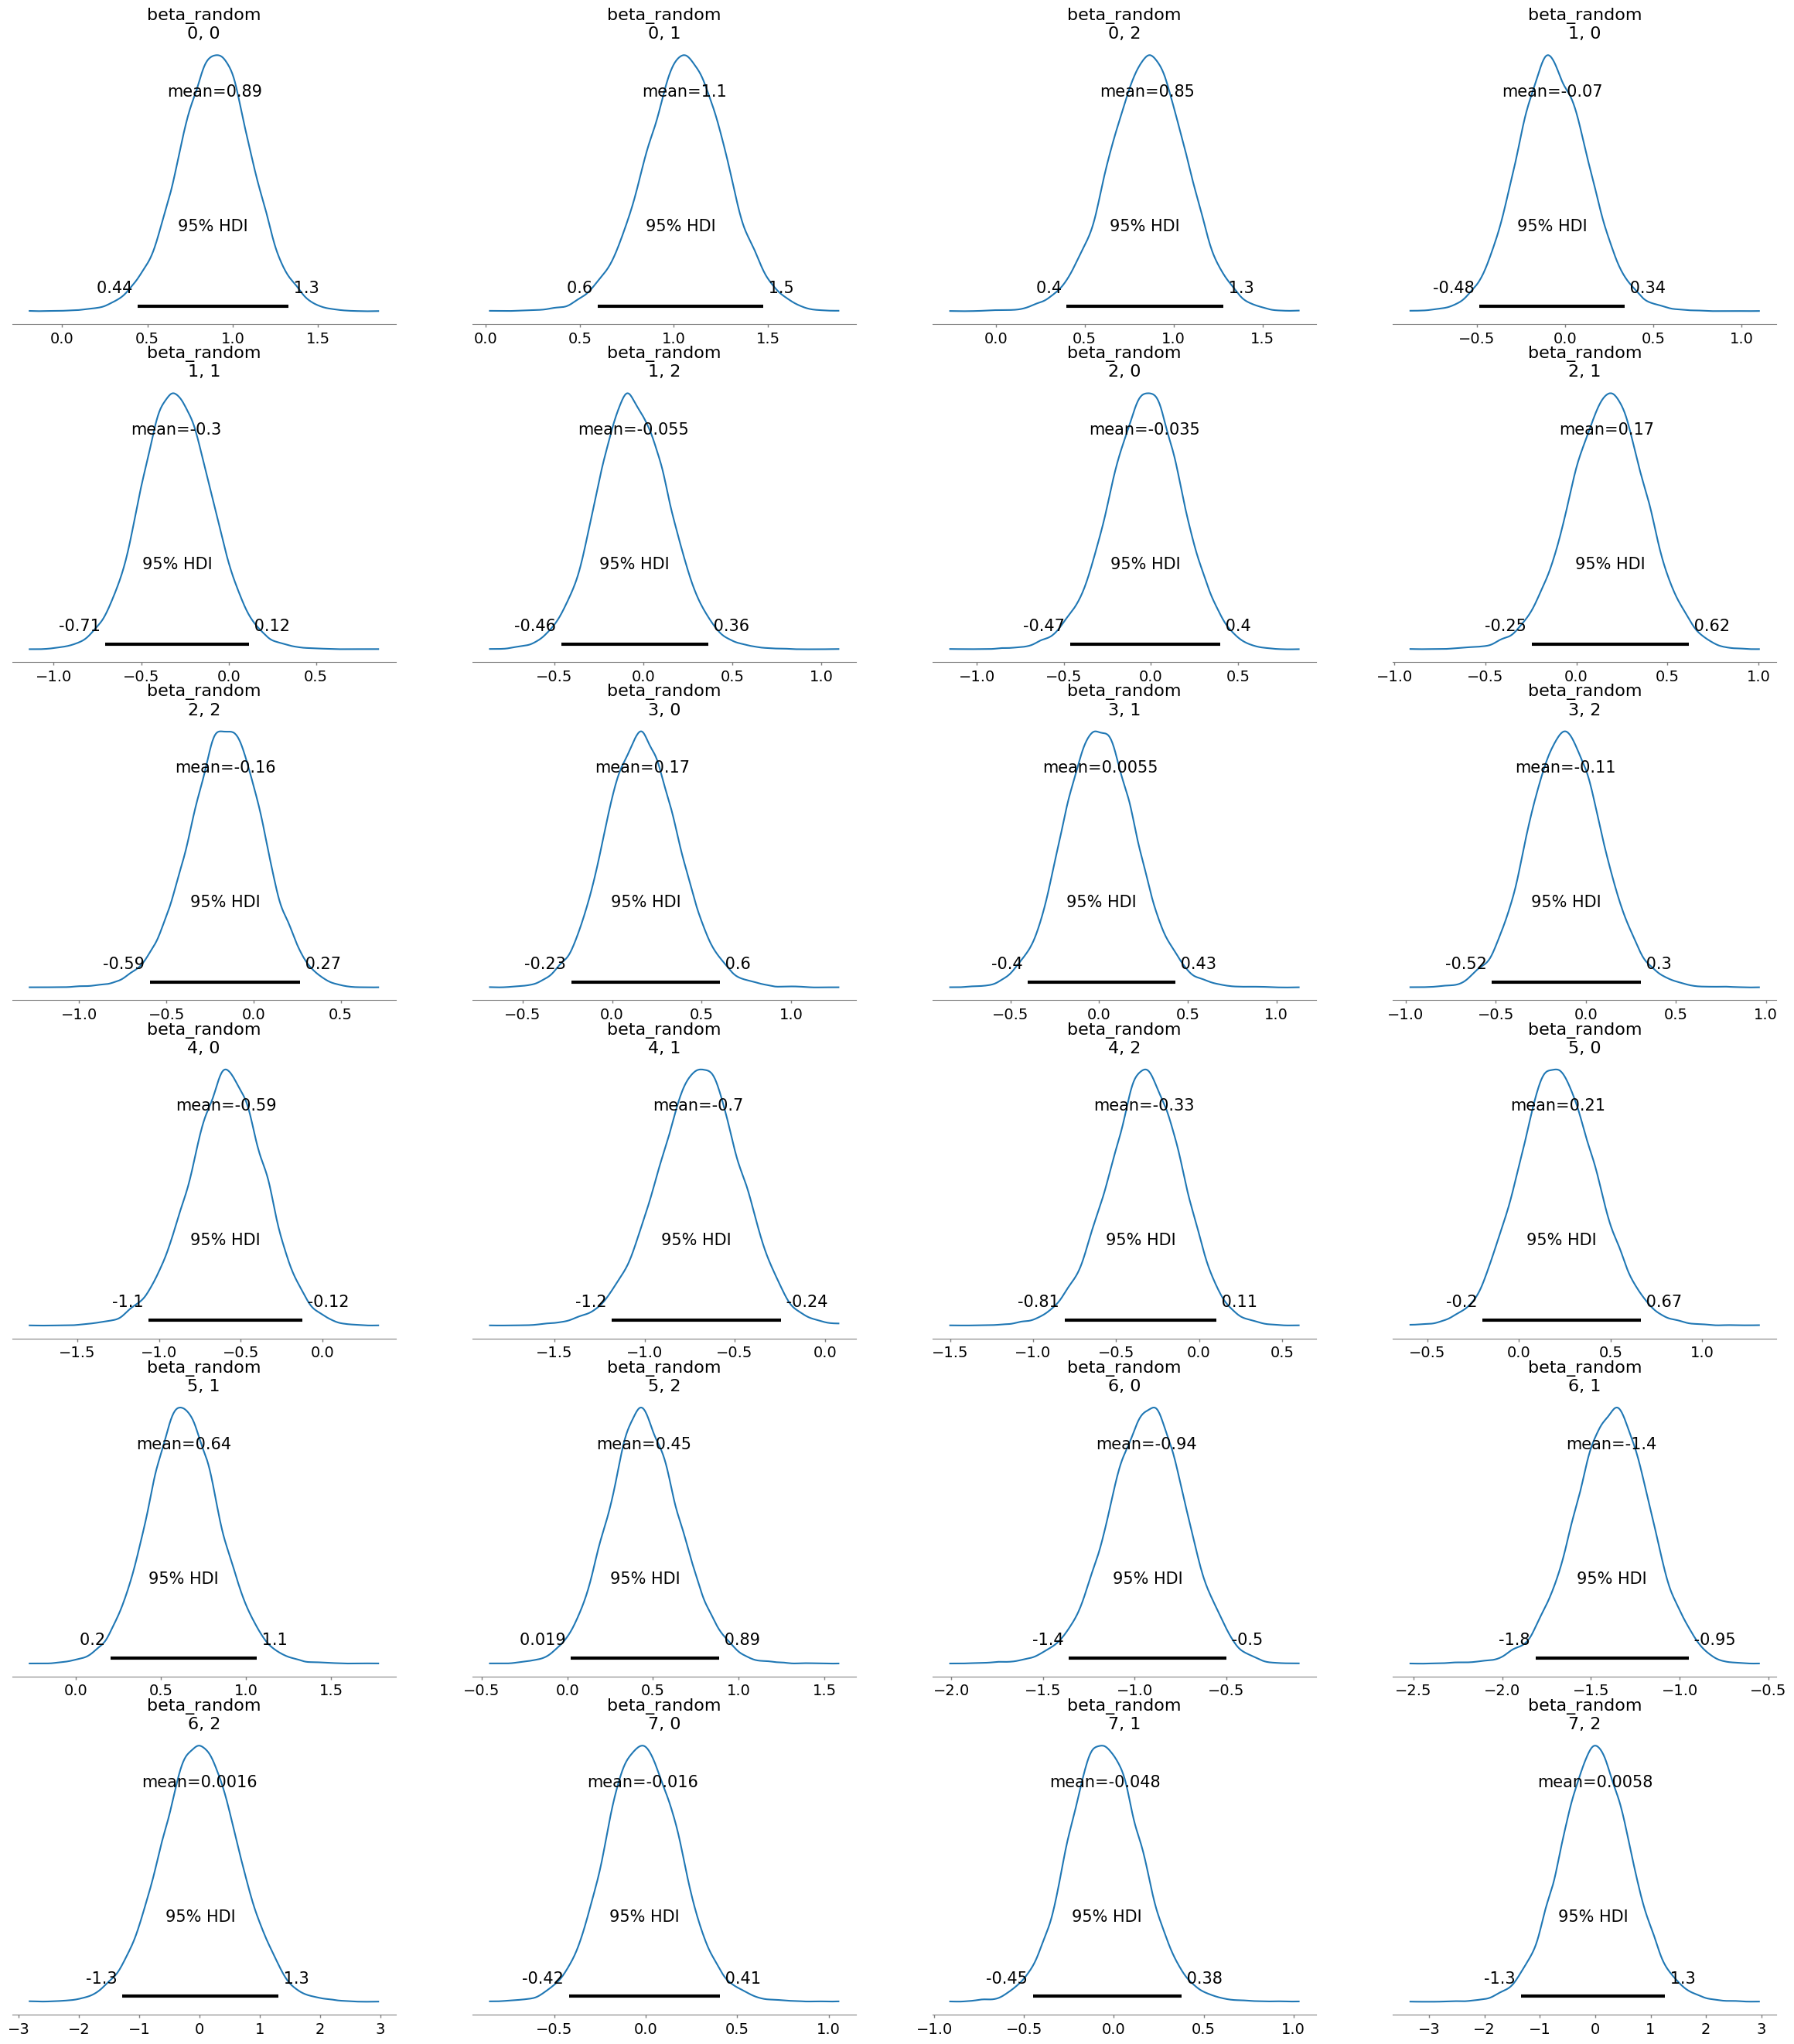

In [49]:
az.plot_posterior(poi_glm1_data, var_names=["beta_random"], hdi_prob=0.95)

array([[<Axes: title={'center': 'alpha\n0'}>,
        <Axes: title={'center': 'alpha\n1'}>,
        <Axes: title={'center': 'alpha\n2'}>,
        <Axes: title={'center': 'alpha\n3'}>],
       [<Axes: title={'center': 'alpha\n4'}>,
        <Axes: title={'center': 'alpha\n5'}>,
        <Axes: title={'center': 'alpha\n6'}>,
        <Axes: title={'center': 'alpha\n7'}>]], dtype=object)

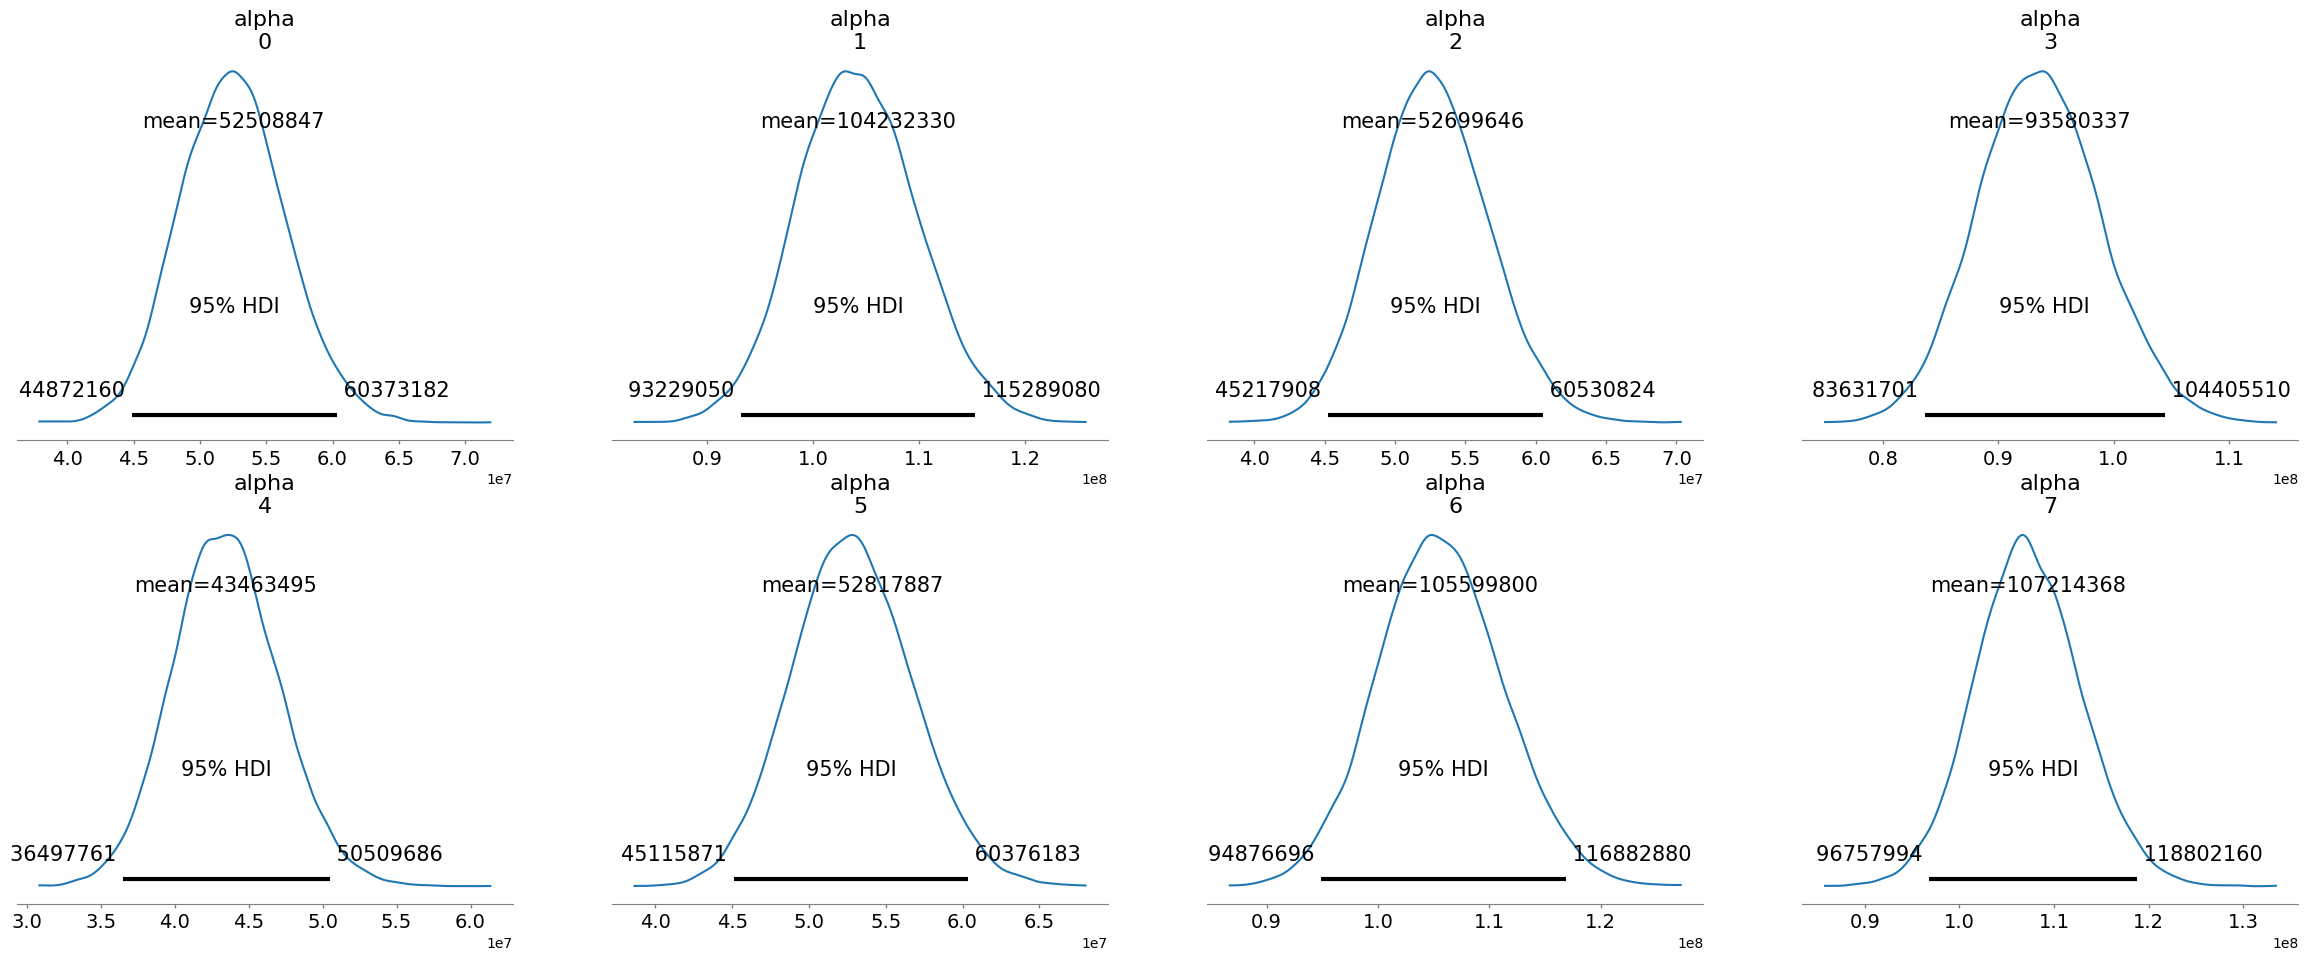

In [50]:
az.plot_posterior(poi_glm1_data, var_names=["alpha"], hdi_prob=0.95)

In [57]:
az.summary(poi_glm1_data, var_names=["beta"], hdi_prob=0.95)
#b0 is the intercept
#b1 is the coefficient for IBU
#b2 is the coefficient for DMSO
#b3 is the coefficient for Temp

#mcse_mean is the Monte Carlo Standard Error of the mean estimate
#mcmse_sd is the Monte Carlo Standard Error of the standard deviation estimate
#ess_bulk is the number of independent samples in the bulk of the posterior(central part of the distribution)
#ess_tail is the number of independent samples in the tails of the posterior(distribution extremes)
#r_hat (Gelman–Rubin diagnostic) convergence diagnostic 


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta[0],-9.663,0.868,-11.323,-7.930,0.016,0.015,3050.0,4018.0,1.0
beta[1],0.000,0.000,-0.001,0.001,0.000,0.000,20649.0,12187.0,1.0
beta[2],0.032,0.003,0.027,0.038,0.000,0.000,23085.0,14473.0,1.0
beta[3],-0.030,0.025,-0.080,0.019,0.000,0.000,2997.0,3724.0,1.0


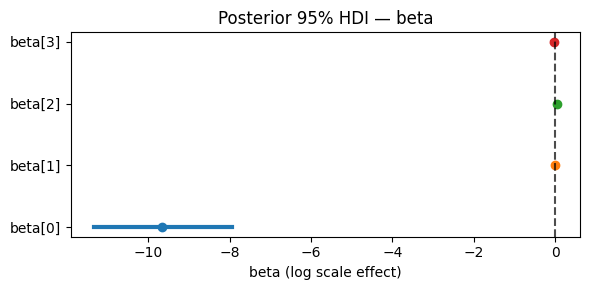

In [59]:
sum_beta = az.summary(poi_glm1_data, var_names=["beta"], hdi_prob=0.95)

names = sum_beta.index.to_list()
mean  = sum_beta["mean"].values
low   = sum_beta["hdi_2.5%"].values
high  = sum_beta["hdi_97.5%"].values
y = np.arange(len(names))

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

plt.figure(figsize=(6, 3))
for i in range(len(names)):
    plt.plot([low[i], high[i]], [y[i], y[i]], lw=3, color=colors[i])
    plt.plot(mean[i], y[i], "o", color=colors[i])

plt.axvline(0, color="black", ls="--", alpha=0.7)
plt.yticks(y, names)
plt.xlabel("beta (log scale effect)")
plt.title("Posterior 95% HDI — beta")
plt.tight_layout()
plt.show()


In [58]:
az.summary(poi_glm1_data, var_names=["beta_random"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"beta_random[0, 0]",0.893,0.222,0.443,1.326,0.004,0.002,3959.0,6037.0,1.0
"beta_random[0, 1]",1.056,0.222,0.596,1.474,0.004,0.002,3897.0,5834.0,1.0
"beta_random[0, 2]",0.850,0.223,0.399,1.279,0.004,0.002,3932.0,6165.0,1.0
"beta_random[1, 0]",-0.070,0.209,-0.484,0.337,0.004,0.003,3227.0,4271.0,1.0
"beta_random[1, 1]",-0.298,0.210,-0.706,0.117,0.004,0.003,3224.0,4184.0,1.0
"beta_random[1, 2]",-0.055,0.209,-0.460,0.364,0.004,0.003,3231.0,4468.0,1.0
"beta_random[2, 0]",-0.035,0.218,-0.466,0.399,0.004,0.002,3657.0,5007.0,1.0
"beta_random[2, 1]",0.168,0.218,-0.246,0.616,0.004,0.002,3657.0,5090.0,1.0
"beta_random[2, 2]",-0.163,0.219,-0.593,0.268,0.004,0.002,3656.0,5079.0,1.0
"beta_random[3, 0]",0.168,0.211,-0.227,0.604,0.004,0.003,3224.0,4445.0,1.0


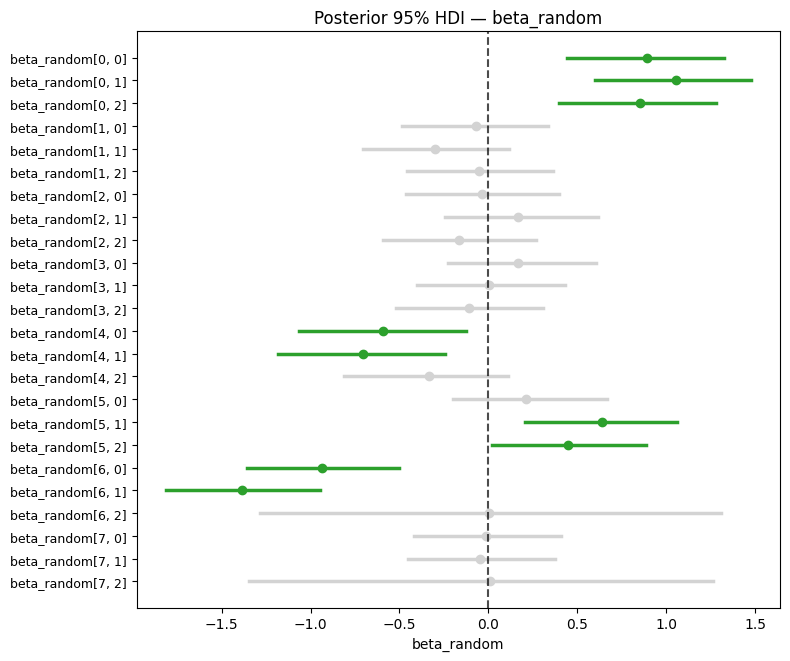

In [63]:
sum_br = az.summary(poi_glm1_data, var_names=["beta_random"], hdi_prob=0.95)

ij = sum_br.index.str.extract(r"beta_random\[(\d+),\s*(\d+)\]").astype(int)
sum_br = sum_br.assign(i=ij[0].values, j=ij[1].values).sort_values(["i", "j"])

labels = sum_br.index.to_list()
mean = sum_br["mean"].values
low = sum_br["hdi_2.5%"].values
high = sum_br["hdi_97.5%"].values
y = np.arange(len(labels))

plt.figure(figsize=(8, max(6, 0.28 * len(labels))))

for k in range(len(labels)):
    color = "tab:green" if (low[k] > 0) or (high[k] < 0) else "lightgray"
    plt.plot([low[k], high[k]], [y[k], y[k]], lw=2.5, color=color)
    plt.plot(mean[k], y[k], "o", color=color)

plt.axvline(0, color="black", ls="--", alpha=0.7)
plt.yticks(y, labels, fontsize=9)
plt.xlabel("beta_random")
plt.title("Posterior 95% HDI — beta_random")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


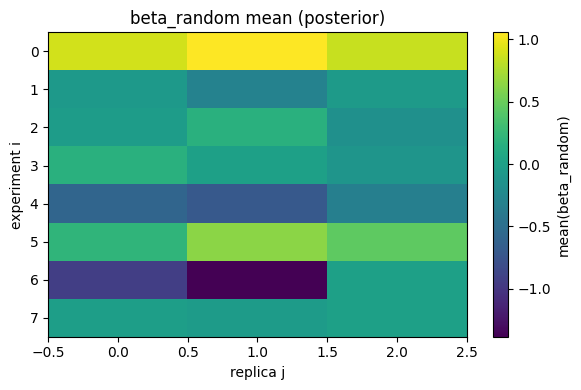

In [60]:
sum_br = az.summary(poi_glm1_data, var_names=["beta_random"], hdi_prob=0.95)

# ricostruisco indici (i,j) parsando il nome "beta_random[6, 2]"
ij = sum_br.index.str.extract(r"beta_random\[(\d+),\s*(\d+)\]").astype(int)
i_idx = ij[0].values
j_idx = ij[1].values

I = i_idx.max() + 1
J = j_idx.max() + 1

mean_mat = np.full((I, J), np.nan)
hdiw_mat = np.full((I, J), np.nan)  # width dell'HDI (incertezza)

for k, (i, j) in enumerate(zip(i_idx, j_idx)):
    mean_mat[i, j] = sum_br["mean"].values[k]
    hdiw_mat[i, j] = sum_br["hdi_97.5%"].values[k] - sum_br["hdi_2.5%"].values[k]

plt.figure(figsize=(6, 4))
plt.imshow(mean_mat, aspect="auto")
plt.colorbar(label="mean(beta_random)")
plt.xlabel("replica j")
plt.ylabel("experiment i")
plt.title("beta_random mean (posterior)")
plt.tight_layout()
plt.show()


In [54]:
az.summary(poi_glm1_data, var_names=["tau_sq","sigma_beta_sq"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau_sq,15.960,11.562,3.445,36.318,0.108,0.266,12649.0,11833.0,1.0
sigma_beta_sq,0.429,0.147,0.200,0.721,0.002,0.002,11433.0,9036.0,1.0


In [55]:
az.summary(poi_glm1_data, var_names=["alpha","mu_chi","sigma_chi"], hdi_prob=0.95)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[0],5.250885e+07,3968558.934,4.487216e+07,6.037318e+07,38780.637,29669.596,10411.0,11249.0,1.0
alpha[1],1.042323e+08,5621960.029,9.322905e+07,1.152891e+08,55814.637,41083.549,10071.0,10853.0,1.0
alpha[2],5.269965e+07,3934549.089,4.521791e+07,6.053082e+07,37993.633,28672.650,10653.0,11707.0,1.0
alpha[3],9.358034e+07,5309692.440,8.363170e+07,1.044055e+08,52236.708,38267.537,10298.0,11739.0,1.0
alpha[4],4.346350e+07,3582632.025,3.649776e+07,5.050969e+07,35725.210,26387.743,10035.0,11099.0,1.0
alpha[5],5.281789e+07,3902808.145,4.511587e+07,6.037618e+07,37503.001,27727.908,10866.0,12743.0,1.0
alpha[6],1.055998e+08,5603618.057,9.487670e+07,1.168829e+08,53388.223,39237.510,10990.0,12254.0,1.0
alpha[7],1.072144e+08,5602610.968,9.675799e+07,1.188022e+08,52506.927,41350.038,11390.0,12531.0,1.0
mu_chi,7.221000e+00,1.020,5.223000e+00,9.238000e+00,0.010,0.007,9842.0,12114.0,1.0
sigma_chi,5.257000e+00,0.547,4.192000e+00,6.348000e+00,0.006,0.004,7833.0,9798.0,1.0


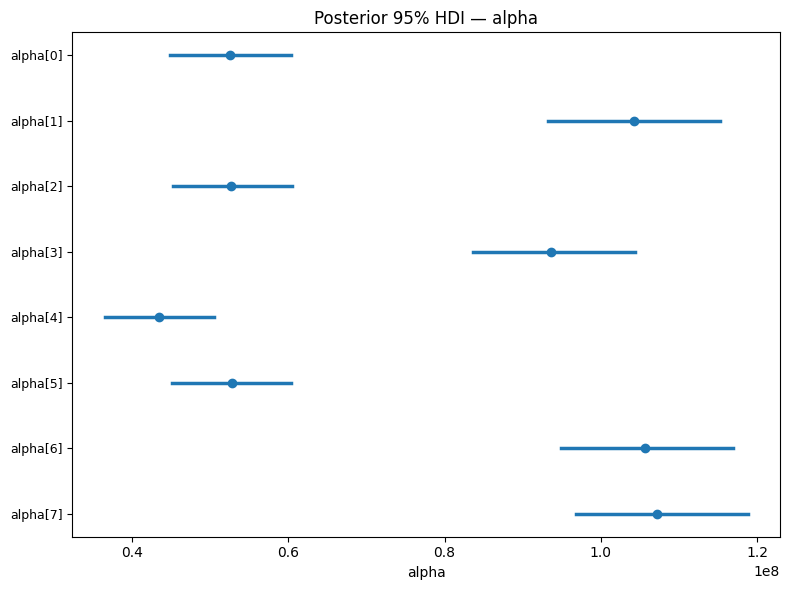

In [64]:
sum_alpha = az.summary(poi_glm1_data, var_names=["alpha"], hdi_prob=0.95)

labels = sum_alpha.index.to_list()
mean = sum_alpha["mean"].values
low = sum_alpha["hdi_2.5%"].values
high = sum_alpha["hdi_97.5%"].values
y = np.arange(len(labels))

plt.figure(figsize=(8, max(6, 0.28 * len(labels))))

for k in range(len(labels)):
    plt.plot([low[k], high[k]], [y[k], y[k]], lw=2.5, color="tab:blue")
    plt.plot(mean[k], y[k], "o", color="tab:blue")

plt.yticks(y, labels, fontsize=9)
plt.xlabel("alpha")
plt.title("Posterior 95% HDI — alpha")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


##### Prior predective check

In [24]:
rng = default_rng(123)

def half_normal(mean,std,size=None):
    return np.abs(rng.normal(mean, std,size=size))

def inv_gamma(a, b):
     # Replicates Stan's inv_gamma(a, b)
    # Stan: Inv-Gamma(shape=a, scale=b)
    U = rng.gamma(shape=a, scale=1.0/b)  
    return 1.0 / U

def prior_predictive(
    Y_obs, D_obs, X, rho_trasc, rho_donor,
    idx_experiment, idx_experiment_replica, idx_donor_experiment,
    n_draws=2000,
    # prior hyperparams (modifica qui per fare sensitivity)
    mu_chi_mean=4.0, 
    mu_chi_sd=1.0,
    sigma_chi_scale=1.0,                       
    ig_a=2.0, ig_b=1.0               # sigma_beta^2 ~ Inv-Gamma(a,b)
):
    Y_obs = np.asarray(Y_obs)
    D_obs = np.asarray(D_obs)
    X = np.asarray(X)
    rho_trasc = np.asarray(rho_trasc)
    rho_donor = np.asarray(rho_donor)

    N, p = X.shape
    I = len(np.unique(idx_experiment))
    J = len(np.unique(idx_experiment_replica))
    M = len(D_obs)

    

    Y_rep_store = np.empty((n_draws, N), dtype=int)
    D_rep_store = np.empty((n_draws, M), dtype=int)


    for d in range(n_draws):
        # --- alpha hierarchy ---
        mu_chi = rng.normal(mu_chi_mean, mu_chi_sd)
        sigma_chi = half_normal(0.0,sigma_chi_scale)
        log_alpha = rng.normal(mu_chi, sigma_chi, size=I)
        alpha = np.exp(log_alpha)

        # --- fixed effects ---
        tau_sq = inv_gamma(ig_a, ig_b)
        tau=np.sqrt(tau_sq)
        beta = rng.normal(0.0, tau, size=p)

        # --- random effects (experiment x replica) ---
        sigma_beta_sq = inv_gamma(ig_a, ig_b)
        sigma_beta = np.sqrt(sigma_beta_sq)
        b = rng.normal(0.0, sigma_beta, size=(I, J))

        # --- build mu for Y ---
        linpred = X @ beta + b[idx_experiment-1, idx_experiment_replica-1]
        mu = alpha[idx_experiment-1] * np.exp(linpred)
        lam = rho_trasc * mu

        if np.any(~np.isfinite(lam)) or lam.max() > 1e8:
            print("DRAW", d)
            print("alpha max:", alpha.max())
            print("linpred max:", linpred.max())
            print("rho_trasc max:", np.max(rho_trasc))
            print("mu max:", np.max(mu))
            print("lam max:", np.max(lam))
            break
        
        # --- simulate Y_rep ---
        Y_rep = rng.poisson(rho_trasc * mu)

        # --- simulate D_rep ---
        D_rate = rho_donor * alpha[idx_donor_experiment-1]
        D_rep = rng.poisson(D_rate)

        # --- summaries for diagnostics ---
    
        Y_rep_store[d, :] = Y_rep
        D_rep_store[d, :] = D_rep

        

    out = {
        "Y_obs": Y_obs, "D_obs": D_obs,
        "Y_rep_store": Y_rep_store,
        "D_rep_store": D_rep_store,

    }
    return out

def ppc_level3(out):
    Y_obs = out["Y_obs"]
    D_obs = out["D_obs"]
    Y_rep = out["Y_rep_store"]  # (draws, N)
    D_rep = out["D_rep_store"]  # (draws, M)

    # one-sided PPC p-values
    pval_Y = np.mean(Y_rep >= Y_obs[None, :], axis=0)
    pval_D = np.mean(D_rep >= D_obs[None, :], axis=0)

    # percentuali di estremi
    extreme_Y = np.mean((pval_Y < 0.05) | (pval_Y > 0.95))
    extreme_D = np.mean((pval_D < 0.05) | (pval_D > 0.95))

    print("PPC Level 3")
    print("Extreme p-values Y (<0.05 or >0.95):", extreme_Y)
    print("Extreme p-values D (<0.05 or >0.95):", extreme_D)

    return pval_Y, pval_D


In [27]:
#prior predictive check
ppc_out = prior_predictive(
    Y_obs=Y, D_obs=D, X=X,
    rho_trasc=rho_trasc, rho_donor=rho_donor,
    idx_experiment=idx_experiment,
    idx_experiment_replica=idx_experiment_replica,
    idx_donor_experiment=idx_donor_experiment,
    n_draws=2000,
    # prior hyperparams
    mu_chi_mean=4.0, 
    mu_chi_sd=1.0,
    sigma_chi_scale=1.0,                       
    ig_a=1.0, ig_b=0.5
)  
pval_Y, pval_D = ppc_level3(ppc_out)    

DRAW 1
alpha max: 614.207996210806
linpred max: 31.25124720879075
rho_trasc max: 0.1
mu max: 3757401481931802.0
lam max: 375740148193180.25
PPC Level 3
Extreme p-values Y (<0.05 or >0.95): 1.0
Extreme p-values D (<0.05 or >0.95): 1.0
